In [1]:
import numpy as np
import matplotlib.pyplot as plt

def sample_exponential(n):
    U = np.random.rand(n)
    U = np.clip(U, 1e-10, 1.0)
    return -np.log(U)

def box_muller(n):
    m = int(np.ceil(n / 2))
    U1 = np.clip(np.random.rand(m), 1e-10, 1.0)
    U2 = np.random.rand(m)
    Z1 = np.sqrt(-2 * np.log(U1)) * np.cos(2 * np.pi * U2)
    Z2 = np.sqrt(-2 * np.log(U1)) * np.sin(2 * np.pi * U2)
    return np.concatenate([Z1, Z2])[:n]

def compute_ecdf(data):
    sorted_data = np.sort(data)
    n = len(sorted_data)
    cumulative = np.arange(1, n + 1) / n
    return sorted_data, cumulative

# Step 4.1
n = 100000
exp_samples = sample_exponential(n)
print(f"Empirical mean: {np.mean(exp_samples):.4f}  (theoretical: 1.0)")
print(f"Empirical var : {np.var(exp_samples):.4f}  (theoretical: 1.0)")



Empirical mean: 1.0049  (theoretical: 1.0)
Empirical var : 1.0143  (theoretical: 1.0)


In [7]:
# Step 4.2
N = 50
M = 10000
table = sample_exponential(M * N).reshape(M, N)
sample_means = table.mean(axis=1)



In [8]:
# Step 4.3
mu = 1.0
sigma2 = 1.0
clt_mean = mu
clt_var = sigma2 / N
print(f"\nCLT predicts: N({clt_mean}, {clt_var})")




CLT predicts: N(1.0, 0.02)


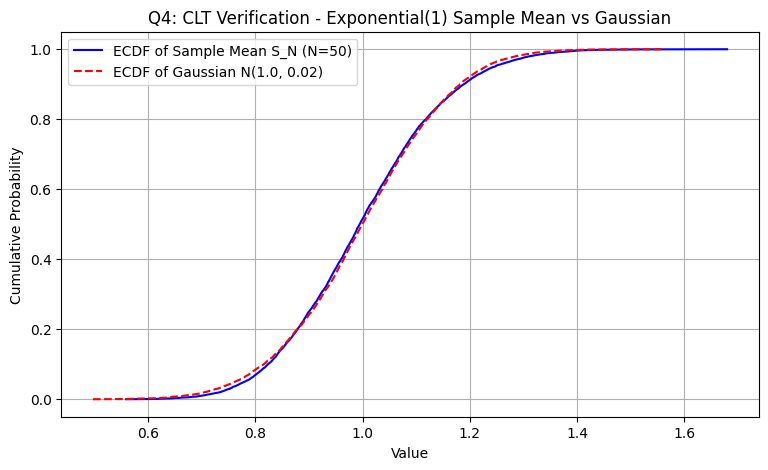

In [ ]:
# Step 4.4
gaussian_samples = clt_mean+np.sqrt(clt_var)*box_muller(M)

x_sn,cdf_sn= compute_ecdf(sample_means)
x_gau,cdf_gau = compute_ecdf(gaussian_samples)

plt.plot(x_sn, cdf_sn, color='blue',label=f'ECDF of Sample Mean S_N (N={N})')
plt.plot(x_gau, cdf_gau, color='red',linestyle='--', label=f'ECDF of Gaussian N({clt_mean}, {clt_var})')
plt.xlabel('Value')
plt.ylabel('Cumulative Probability')
plt.title('Q4: CLT Verification - Exponential(1) Sample Mean vs Gaussian')
plt.legend()
plt.grid(True)
plt.show()